In [1]:
import pickle
import numpy as np

model = 'mle'
d = 50
n = 500

In [2]:
import pickle
import numpy as np
import torch
import os

# ==========================================
# 1. 路径与基本参数设置
# ==========================================
# 使用原始字符串 r"" 避免 \U, \2 等转义报错
file_path = r"C:\Users\24300\Desktop\Ada_S\results\robust_mle_n500d50_AdaRHD_gd_lr0.1.pickle"

with open(file_path, 'rb') as handle:
    data = pickle.load(handle)

# ==========================================
# 2. 处理 Hypergrad Norm (取累计最小值 cummin)
# ==========================================
all_gradnorms = data['total_hgradnorm']
new_all_gradnorms = []

for i in range(len(all_gradnorms)):
    # 确保数据是 Tensor 类型，以便使用 cummin
    g_tensor = all_gradnorms[i]
    if not isinstance(g_tensor, torch.Tensor):
        g_tensor = torch.tensor(g_tensor)
    
    # 沿着 epoch 维度取累计最小值（dim=1）
    # 如果数据本身就是一维的，注意 reshape
    new_all_gradnorms.append(g_tensor.cummin(dim=1)[0])

all_gradnorms = new_all_gradnorms
num_experiments = len(all_gradnorms)
print(f"Found {num_experiments} experiments in the data")

# ==========================================
# 3. 填充与对齐数据
# ==========================================
# 动态获取当前数据的最大 epoch 数，防止截断
max_epochs = 0
for g in all_gradnorms:
    max_epochs = max(max_epochs, g.numel())
print(f"Aligning all experiments to {max_epochs} epochs")

train_gradnorms = []
times = []

# 处理时间数据 (取累计和 cumsum)
all_times = data['runtime']

for i in range(num_experiments):
    # --- 处理 Grad Norm ---
    # .reshape(-1) 展平为一维，.cpu().numpy() 转换为 numpy
    gn = all_gradnorms[i].reshape(-1).cpu().numpy()
    if len(gn) < max_epochs:
        gn = np.pad(gn, (0, max_epochs - len(gn)), 'edge')
    else:
        gn = gn[:max_epochs]
    train_gradnorms.append(gn)

    # --- 处理 Time ---
    t_tensor = all_times[i]
    if not isinstance(t_tensor, torch.Tensor):
        t_tensor = torch.tensor(t_tensor)
    
    # 计算累计耗时
    t_cumsum = t_tensor.cumsum(dim=1)[0].reshape(-1).cpu().numpy()
    if len(t_cumsum) < max_epochs:
        t_cumsum = np.pad(t_cumsum, (0, max_epochs - len(t_cumsum)), 'edge')
    else:
        t_cumsum = t_cumsum[:max_epochs]
    times.append(t_cumsum)

# ==========================================
# 4. 转换成最终矩阵
# ==========================================
train_gradnorms_AdaRHD_gd = np.array(train_gradnorms)
AdaRHD_gd_times = np.array(times)

print(f"Successfully processed: {train_gradnorms_AdaRHD_gd.shape}")

Found 5 experiments in the data
Aligning all experiments to 307 epochs
Successfully processed: (5, 307)


In [3]:
import pickle
import numpy as np
import torch
import os

# ==========================================
# 1. 路径设置 (使用 r"" 避免 Windows 路径转义错误)
# ==========================================
file_path_cg = r"C:\Users\24300\Desktop\Ada_S\results\robust_mle_n500d50_AdaRHD_cg_lr0.1.pickle"

with open(file_path_cg, 'rb') as handle:
    data_cg = pickle.load(handle)

# ==========================================
# 2. 处理 Hypergrad Norm (取累计最小值)
# ==========================================
all_gradnorms = data_cg['total_hgradnorm']
new_all_gradnorms = []

for i in range(len(all_gradnorms)):
    # 确保是 Tensor 以使用 cummin
    g_tensor = all_gradnorms[i]
    if not isinstance(g_tensor, torch.Tensor):
        g_tensor = torch.tensor(g_tensor)
    
    # cummin(dim=1)[0] 获取目前为止出现的最小值
    new_all_gradnorms.append(g_tensor.cummin(dim=1)[0])

all_gradnorms = new_all_gradnorms
num_experiments = len(all_gradnorms)
print(f"Found {num_experiments} experiments in CG data")

# ==========================================
# 3. 填充与对齐 (Padding)
# ==========================================
# 设置目标 Epoch 长度，CG 通常是 301
max_epochs = 301 

train_gradnorms_cg_list = []
times_cg_list = []

all_times = data_cg['runtime']

for i in range(num_experiments):
    # --- 处理 Grad Norm ---
    # 展平并转为 numpy
    gn = all_gradnorms[i].reshape(-1).cpu().numpy()
    if len(gn) < max_epochs:
        gn = np.pad(gn, (0, max_epochs - len(gn)), 'constant', constant_values=gn[-1])
    else:
        gn = gn[:max_epochs]
    train_gradnorms_cg_list.append(gn)

    # --- 处理 Time (累加耗时) ---
    t_tensor = all_times[i]
    if not isinstance(t_tensor, torch.Tensor):
        t_tensor = torch.tensor(t_tensor)
    
    # 计算累计耗时 cumsum
    t_cumsum = t_tensor.cumsum(dim=1)[0].reshape(-1).cpu().numpy()
    if len(t_cumsum) < max_epochs:
        t_cumsum = np.pad(t_cumsum, (0, max_epochs - len(t_cumsum)), 'constant', constant_values=t_cumsum[-1])
    else:
        t_cumsum = t_cumsum[:max_epochs]
    times_cg_list.append(t_cumsum)

# ==========================================
# 4. 转换为最终 Numpy 矩阵
# ==========================================
train_gradnorms_AdaRHD_cg = np.array(train_gradnorms_cg_list)
AdaRHD_cg_times = np.array(times_cg_list)

print(f"CG Data processed. Shape: {train_gradnorms_AdaRHD_cg.shape}")

Found 1 experiments in CG data
CG Data processed. Shape: (1, 301)


In [4]:
method = 'RHGD'
methodopt = '20'
with open(f'../results/robust_{model}_n{n}d{d}_{method}_{methodopt}_lr0.1.pickle', 'rb') as handle:
    data = pickle.load(handle)

# Get the accuracy data from the data dictionary
all_gradnorms = data['total_hgradnorm']
new_all_gradnorms = []
for i in range(len(all_gradnorms)):
    new_all_gradnorms.append(all_gradnorms[i].cummin(dim=1)[0])
all_gradnorms = new_all_gradnorms

# Determine how many experiments we have
num_experiments = len(all_gradnorms)
print(f"Found {num_experiments} experiments in the data")

# Prepare arrays for storing padded data
train_gradnorms = []
max_epochs = 301  # Target length for all experiments

# Process each experiment
for i in range(num_experiments):
    # Extract accuracy data and reshape
    train_gradnorm = all_gradnorms[i].reshape(-1)

    # Get the number of epochs in this experiment
    num_epochs = len(train_gradnorm)
    print(f"Experiment {i+1} has {num_epochs} epochs")
    
    # If less than max_epochs, pad with the last value
    if num_epochs < max_epochs:
        train_gradnorm = np.pad(train_gradnorm, (0, max_epochs - num_epochs), 
                            'constant', constant_values=train_gradnorm[-1])
    else:
        # If more than max_epochs, truncate
        train_gradnorm = train_gradnorm[:max_epochs]
        train_gradnorm = train_gradnorm.numpy()
    

    # Add to our list
    train_gradnorms.append(train_gradnorm)


# Convert lists to numpy arrays for easier manipulation
train_gradnorms_RHGD_20 = np.array(train_gradnorms)

all_times = data['runtime']
new_all_times = []
for i in range(len(all_times)):
    new_all_times.append(all_times[i].cumsum(dim=1)[0])
all_times = new_all_times

times = []
# Process each experiment
for i in range(num_experiments):
    # Extract accuracy data and reshape
    time = all_times[i].reshape(-1)

    # Get the number of epochs in this experiment
    num_epochs = len(time)
    print(f"Experiment {i+1} has {num_epochs} epochs")
    
    # If less than max_epochs, pad with the last value
    if num_epochs < max_epochs:
        time = np.pad(time, (0, max_epochs - num_epochs),
                      'constant', constant_values=time[-1])
    else:
        # If more than max_epochs, truncate
        time = time[:max_epochs]
        time = time.numpy()

    # Add to our list
    times.append(time)

# Convert lists to numpy arrays for easier manipulation
RHGD_20_times = np.array(times)


Found 5 experiments in the data
Experiment 1 has 306 epochs
Experiment 2 has 306 epochs
Experiment 3 has 306 epochs
Experiment 4 has 306 epochs
Experiment 5 has 306 epochs
Experiment 1 has 306 epochs
Experiment 2 has 306 epochs
Experiment 3 has 306 epochs
Experiment 4 has 306 epochs
Experiment 5 has 306 epochs


In [5]:
method = 'RHGD'
methodopt = '50'
with open(f'../results/robust_{model}_n{n}d{d}_{method}_{methodopt}_lr0.1.pickle', 'rb') as handle:
    data = pickle.load(handle)

# Get the accuracy data from the data dictionary
all_gradnorms = data['total_hgradnorm']
new_all_gradnorms = []
for i in range(len(all_gradnorms)):
    new_all_gradnorms.append(all_gradnorms[i].cummin(dim=1)[0])
all_gradnorms = new_all_gradnorms

# Determine how many experiments we have
num_experiments = len(all_gradnorms)
print(f"Found {num_experiments} experiments in the data")

# Prepare arrays for storing padded data
train_gradnorms = []
max_epochs = 301  # Target length for all experiments

# Process each experiment
for i in range(num_experiments):
    # Extract accuracy data and reshape
    train_gradnorm = all_gradnorms[i].reshape(-1)

    # Get the number of epochs in this experiment
    num_epochs = len(train_gradnorm)
    print(f"Experiment {i+1} has {num_epochs} epochs")
    
    # If less than max_epochs, pad with the last value
    if num_epochs < max_epochs:
        train_gradnorm = np.pad(train_gradnorm, (0, max_epochs - num_epochs), 
                            'constant', constant_values=train_gradnorm[-1])
    else:
        # If more than max_epochs, truncate
        train_gradnorm = train_gradnorm[:max_epochs]
        train_gradnorm = train_gradnorm.numpy()
    

    # Add to our list
    train_gradnorms.append(train_gradnorm)


# Convert lists to numpy arrays for easier manipulation
train_gradnorms_RHGD_50 = np.array(train_gradnorms)

all_times = data['runtime']
new_all_times = []
for i in range(len(all_times)):
    new_all_times.append(all_times[i].cumsum(dim=1)[0])
all_times = new_all_times

times = []
# Process each experiment
for i in range(num_experiments):
    # Extract accuracy data and reshape
    time = all_times[i].reshape(-1)

    # Get the number of epochs in this experiment
    num_epochs = len(time)
    print(f"Experiment {i+1} has {num_epochs} epochs")
    
    # If less than max_epochs, pad with the last value
    if num_epochs < max_epochs:
        time = np.pad(time, (0, max_epochs - num_epochs),
                      'constant', constant_values=time[-1])
    else:
        # If more than max_epochs, truncate
        time = time[:max_epochs]
        time = time.numpy()

    # Add to our list
    times.append(time)

# Convert lists to numpy arrays for easier manipulation
RHGD_50_times = np.array(times)


Found 1 experiments in the data
Experiment 1 has 51 epochs
Experiment 1 has 51 epochs


In [6]:
import pickle
import numpy as np
import torch
import os

# ==========================================
# 1. 路径设置 (针对 AdaRHD-S, 1000 Epochs)
# ==========================================
# 使用原始字符串 r"" 避免 Windows 路径反斜杠报错
file_path_s = r"C:\Users\24300\Desktop\Ada_S\results\robust_mle_n500_d50_AdaRHD_S_lr0.1.pickle"

with open(file_path_s, 'rb') as handle:
    data_s = pickle.load(handle)

# ==========================================
# 2. 处理 Hypergrad Norm (取累计最小值)
# ==========================================
all_gradnorms = data_s['total_hgradnorm']
new_all_gradnorms = []

for i in range(len(all_gradnorms)):
    # 转换为 Tensor 以使用 cummin
    g_tensor = all_gradnorms[i]
    if not isinstance(g_tensor, torch.Tensor):
        g_tensor = torch.tensor(g_tensor)
    
    # 获取每一轮的累计最小值（保持曲线单调递减，展示最佳收敛点）
    new_all_gradnorms.append(g_tensor.cummin(dim=1)[0])

all_gradnorms = new_all_gradnorms
num_experiments = len(all_gradnorms)
print(f"Found {num_experiments} experiments in AdaRHD-S data")

# ==========================================
# 3. 填充与对齐 (针对 1000 次 Epoch)
# ==========================================
# 设定为 1001 (包括初始状态 Epoch 0)
max_epochs = 1001 

train_gradnorms_s_list = []
times_s_list = []
all_times = data_s['runtime']

for i in range(num_experiments):
    # --- 处理 Grad Norm ---
    gn = all_gradnorms[i].reshape(-1).cpu().numpy()
    num_epochs_actual = len(gn)
    
    if num_epochs_actual < max_epochs:
        # 如果跑不满 1000 次，用最后的值填充
        gn = np.pad(gn, (0, max_epochs - num_epochs_actual), 'constant', constant_values=gn[-1])
    else:
        # 如果超过了（比如包含 Epoch 0），进行截断
        gn = gn[:max_epochs]
    train_gradnorms_s_list.append(gn)

    # --- 处理 Time (累加总耗时) ---
    t_tensor = all_times[i]
    if not isinstance(t_tensor, torch.Tensor):
        t_tensor = torch.tensor(t_tensor)
    
    # cumsum 计算到每个 epoch 为止的累计时间
    t_cumsum = t_tensor.cumsum(dim=1)[0].reshape(-1).cpu().numpy()
    if len(t_cumsum) < max_epochs:
        t_cumsum = np.pad(t_cumsum, (0, max_epochs - len(t_cumsum)), 'constant', constant_values=t_cumsum[-1])
    else:
        t_cumsum = t_cumsum[:max_epochs]
    times_s_list.append(t_cumsum)

# ==========================================
# 4. 转换为最终 Numpy 矩阵
# ==========================================
train_gradnorms_AdaRHD_S = np.array(train_gradnorms_s_list)
AdaRHD_S_times = np.array(times_s_list)

print(f"AdaRHD-S Data processed.")
print(f"Matrix shape: {train_gradnorms_AdaRHD_S.shape} (Runs x Epochs)")

Found 5 experiments in AdaRHD-S data
AdaRHD-S Data processed.
Matrix shape: (5, 1001) (Runs x Epochs)


In [7]:
# 计算各算法多轮实验的 Hypergradient Norm 均值 (axis=0 代表对 runs 取平均)

# 1. Single-loop 算法 (AdaRHD-S, 设定为 1000 次 Epoch)
mean_train_gradnorm_AdaRHD_S = np.mean(train_gradnorms_AdaRHD_S, axis=0)

# 2. Double-loop CG 方法 (AdaRHD-cg, 设定为 300 次 Epoch)
mean_train_gradnorm_AdaRHD_cg = np.mean(train_gradnorms_AdaRHD_cg, axis=0)

# 3. Double-loop GD 方法 (AdaRHD-gd, 设定为 500 次 Epoch)
mean_train_gradnorm_AdaRHD_gd = np.mean(train_gradnorms_AdaRHD_gd, axis=0)

# 4. RHGD-50 方法 (根据你刚才处理生成的变量名 train_gradnorms_RHGD_50)
mean_train_gradnorm_RHGD50 = np.mean(train_gradnorms_RHGD_50, axis=0)

# 5. RHGD-20 方法 (根据你刚才处理生成的变量名 train_gradnorms_RHGD_20)
mean_train_gradnorm_RHGD20 = np.mean(train_gradnorms_RHGD_20, axis=0)

In [8]:
# 计算各算法多轮实验的累计运行时间均值 (axis=0 代表对 runs 取平均)

# 1. Single-loop 算法的时间均值 (1000 Epochs)
mean_time_AdaRHD_S = np.mean(AdaRHD_S_times, axis=0)

# 2. Double-loop CG 方法的时间均值 (300 Epochs)
mean_time_AdaRHD_cg = np.mean(AdaRHD_cg_times, axis=0)

# 3. Double-loop GD 方法的时间均值 (500 Epochs)
mean_time_AdaRHD_gd = np.mean(AdaRHD_gd_times, axis=0)

# 4. RHGD-50 方法的时间均值 (根据你之前生成的 RHGD_50_times)
mean_time_RHGD50 = np.mean(RHGD_50_times, axis=0)

# 5. RHGD-20 方法的时间均值 (根据你之前生成的 RHGD_20_times)
mean_time_RHGD20 = np.mean(RHGD_20_times, axis=0)

图像已保存至: ../fig/robust_mle_n500d50_timeVSgradnorms_550s.pdf (横坐标已锁定为 550s)


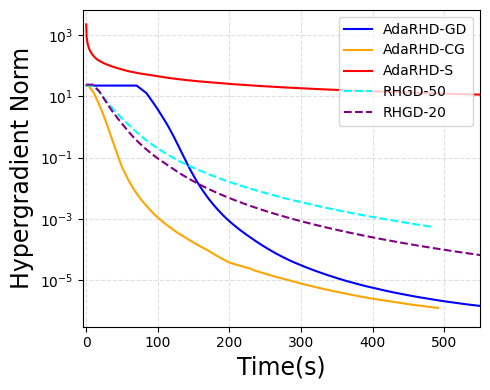

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import os

# 创建画布
plt.figure(figsize=(5, 4))

# --- 1. 绘制 AdaRHD 系列 (实线) ---
# AdaRHD-GD (蓝色)
plt.semilogy(mean_time_AdaRHD_gd, mean_train_gradnorm_AdaRHD_gd, 
             color='blue', label='AdaRHD-GD', linewidth=1.5)

# AdaRHD-CG (橙色)
plt.semilogy(mean_time_AdaRHD_cg, mean_train_gradnorm_AdaRHD_cg, 
             color='orange', label='AdaRHD-CG', linewidth=1.5)

# AdaRHD-S (红色)
plt.semilogy(mean_time_AdaRHD_S, mean_train_gradnorm_AdaRHD_S, 
             color='red', label='AdaRHD-S', linewidth=1.5)

# --- 2. 绘制 RHGD 系列 (虚线) ---
# RHGD-50 (青色)
plt.semilogy(mean_time_RHGD50, mean_train_gradnorm_RHGD50, 
             color='cyan', label='RHGD-50', linewidth=1.5, linestyle='--')

# RHGD-20 (紫色)
plt.semilogy(mean_time_RHGD20, mean_train_gradnorm_RHGD20, 
             color='purple', label='RHGD-20', linewidth=1.5, linestyle='--')

# --- 3. 设置坐标轴与标签 ---
plt.xlabel('Time(s)', fontsize=17)
# 核心修改：统一横坐标到 550
plt.xlim([-5, 550]) 
plt.ylabel('Hypergradient Norm', fontsize=17)

# --- 4. 图表细节优化 ---
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, which="both", linestyle='--', alpha=0.4)
plt.tight_layout()

# --- 5. 保存与展示 ---
os.makedirs('../fig', exist_ok=True)
save_path = f'../fig/robust_mle_n{n}d{d}_timeVSgradnorms_550s.pdf'
plt.savefig(save_path, format='pdf', bbox_inches='tight')

print(f"图像已保存至: {save_path} (横坐标已锁定为 550s)")
plt.show()